In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import LabelEncoder

**assigning ranges and values for the dataset**

In [2]:
# simulation configuration
NUM_TRAINS     = 120       
RANDOM_SEED    = 42 

# numerical feature ranges 
DEPT_HOUR_RANGE       = (0, 23)    
DISTANCE_KM_RANGE     = (424, 487)  
SPEED_KMPH_RANGE      = (46, 107)    
AVG_DELAY_MIN_RANGE   = (1, 39)    
STOPS_RANGE           = (0, 18)     
DURATION_MIN_RANGE    = (248, 635) 

# categorical feature options
TRAIN_TYPES = [
    'Vande Bharat', 'Shatabdi', 'Rajdhani', 'Duronto', 'Tejas',
    'Garib Rath', 'Humsafar', 'Sampark Kranti', 'Amrit Bharat',
    'AC SuperFast', 'SuperFast', 'Express'
]
PRIORITIES = [
    'Highest', 'Very High', 'High', 'Medium-High',
    'Medium', 'Medium-Low', 'Low', 'Lowest'
]
SPEED_CATEGORIES = ['fast', 'medium', 'slow']

print(f"Configuration loaded. Generating {NUM_TRAINS} synthetic train records")

Configuration loaded. Generating 120 synthetic train records


**Generating Synthetic (Unseen) Train Data**

In [3]:
rng = np.random.default_rng(RANDOM_SEED)

dept_hours   = rng.integers(*DEPT_HOUR_RANGE, endpoint=True, size=NUM_TRAINS)
arr_hours    = (dept_hours + rng.integers(4, 11, size=NUM_TRAINS)) % 24
distances    = rng.integers(*DISTANCE_KM_RANGE, endpoint=True, size=NUM_TRAINS)
speeds       = rng.integers(*SPEED_KMPH_RANGE,  endpoint=True, size=NUM_TRAINS)
delays       = rng.integers(*AVG_DELAY_MIN_RANGE, endpoint=True, size=NUM_TRAINS)
stops        = rng.integers(*STOPS_RANGE, endpoint=True, size=NUM_TRAINS)
durations    = rng.integers(*DURATION_MIN_RANGE, endpoint=True, size=NUM_TRAINS)
peak_hrs     = [7, 8, 9, 17, 18, 19, 20]
dept_peak    = [1 if h in peak_hrs else 0 for h in dept_hours]
arr_peak     = [1 if h in peak_hrs else 0 for h in arr_hours]
day_of_week  = rng.integers(0, 7, size=NUM_TRAINS)
is_weekend   = [1 if d >= 5 else 0 for d in day_of_week]
is_overnight = [1 if a < d else 0 for d, a in zip(dept_hours, arr_hours)]
speed_cats   = rng.choice(SPEED_CATEGORIES, size=NUM_TRAINS)
train_types  = rng.choice(TRAIN_TYPES, size=NUM_TRAINS)
priorities   = rng.choice(PRIORITIES, size=NUM_TRAINS)
train_nos    = rng.integers(10000, 90000, size=NUM_TRAINS)

sim_df = pd.DataFrame({
    'Train_No'            : train_nos,
    'Distance_km'         : distances,
    'Speed_kmph'          : speeds,
    'Average_delay_min'   : delays,
    'dept_hour'           : dept_hours,
    'arr_hour'            : arr_hours,
    'duration_min'        : durations,
    'stops'               : stops,
    'departure_peak_flag' : dept_peak,
    'arrival_peak_flag'   : arr_peak,
    'day_of_week'         : day_of_week,
    'is_weekend'          : is_weekend,
    'is_overnight_train'  : is_overnight,
    'speed_category'      : speed_cats,
    'train_type'          : train_types,
    'priority'            : priorities,
})

print(f"Generated {len(sim_df)} synthetic train records")
sim_df.head(8)

Generated 120 synthetic train records


,Train_No,Distance_km,Speed_kmph,Average_delay_min,dept_hour,arr_hour,duration_min,stops,departure_peak_flag,arrival_peak_flag,day_of_week,is_weekend,is_overnight_train,speed_category,train_type,priority
0,19164,432,98,12,2,9,301,11,0,1,2,0,0,fast,Express,Lowest
1,31986,461,101,33,18,2,609,14,1,0,4,0,1,medium,Express,Medium-High
2,53973,430,59,10,15,23,575,14,0,0,6,1,0,slow,Express,Lowest
3,80924,465,101,32,10,17,294,2,0,1,0,0,0,fast,Humsafar,Low
4,79307,464,53,19,10,19,552,15,0,1,0,0,0,slow,Rajdhani,Medium-Low
5,25007,429,78,10,20,3,293,10,1,0,0,0,1,medium,SuperFast,Lowest
6,64345,472,75,14,2,6,527,6,0,0,1,0,0,medium,AC SuperFast,Medium
7,16784,450,65,21,16,1,282,9,0,0,0,0,1,fast,Express,Medium-Low


**Preprocessing**

In [4]:
# Sort by departure hour
sim_df = sim_df.sort_values(by='dept_hour').reset_index(drop=True)

# Compute headway
sim_df['headway'] = sim_df['dept_hour'].diff().fillna(0)

# Label-encode categorical columns 
cat_cols = ['train_type', 'priority']
enc = LabelEncoder()

# Fit on the FULL set of known categories so encoding is consistent
enc.fit(TRAIN_TYPES)
sim_df['train_type'] = enc.transform(sim_df['train_type'])

enc.fit(PRIORITIES)
sim_df['priority'] = enc.transform(sim_df['priority'])

sim_df[['dept_hour','headway','train_type','priority']].head()

,dept_hour,headway,train_type,priority
0,0,0.0,1,6
1,0,0.0,4,3
2,1,1.0,1,3
3,1,0.0,11,1
4,1,0.0,9,3


In [5]:
# Aggregate to hourly level to analyze and predict train throughput at an horly level, rather than for each individual train
hourly_sim = sim_df.groupby('dept_hour').agg(
    headway        = ('headway', 'mean'),
    num_trains     = ('train_type', 'count'),
    priority_trains = ('priority', 'sum')
).reset_index()

# actual train count per hour
hourly_sim['actual_throughput'] = hourly_sim['num_trains']

print(f"Hourly aggregation: {len(hourly_sim)} distinct departure hours")
hourly_sim.head(8)

Hourly aggregation: 23 distinct departure hours


,dept_hour,headway,num_trains,priority_trains,actual_throughput
0,0,0.000000,2,9,2
1,1,0.250000,4,7,4
2,2,0.166667,6,21,6
3,3,0.142857,7,30,7
4,4,0.200000,5,14,5
5,5,0.250000,4,13,4
6,6,0.333333,3,8,3
7,7,0.333333,3,14,3


**Prediction on Simulation**

In [6]:
# Load pre-trained model and scaler, then predict on simulation
import joblib
features = ['dept_hour', 'headway', 'priority_trains']
X_sim = hourly_sim[features]

scaler = joblib.load('scaler.pkl')
best_model = joblib.load('throughput_model.pkl')

X_sim_scaled = scaler.transform(X_sim)

hourly_sim['predicted_throughput'] = best_model.predict(X_sim_scaled)

hourly_sim[['dept_hour','actual_throughput','predicted_throughput']].round(2)

,dept_hour,actual_throughput,predicted_throughput
0,0,2,2.18
1,1,4,0.86
2,2,6,5.97
3,3,7,6.42
4,4,5,3.44
5,5,4,2.77
6,6,3,1.94
7,7,3,4.28
8,8,5,3.49
9,9,3,2.31


**Results Summary**

In [7]:
# Summary statistics for the simulation
max_hour  = hourly_sim.loc[hourly_sim['predicted_throughput'].idxmax(), 'dept_hour']
max_pred  = hourly_sim['predicted_throughput'].max()
min_hour  = hourly_sim.loc[hourly_sim['predicted_throughput'].idxmin(), 'dept_hour']
min_pred  = hourly_sim['predicted_throughput'].min()
avg_pred  = hourly_sim['predicted_throughput'].mean()
total     = hourly_sim['actual_throughput'].sum()

print(" SIMULATION RESULTS SUMMARY")
print(f" Peak throughput hour  : {int(max_hour):02d}:00  ->  {max_pred:.2f} trains/hr")
print(f" Lowest throughput hour  : {int(min_hour):02d}:00  ->  {min_pred:.2f} trains/hr")
print(f" Average predicted throughput: {avg_pred:.2f} trains/hr")

 SIMULATION RESULTS SUMMARY
 Peak throughput hour  : 18:00  ->  10.41 trains/hr
 Lowest throughput hour  : 01:00  ->  0.86 trains/hr
 Average predicted throughput: 4.69 trains/hr


**Visualizations**

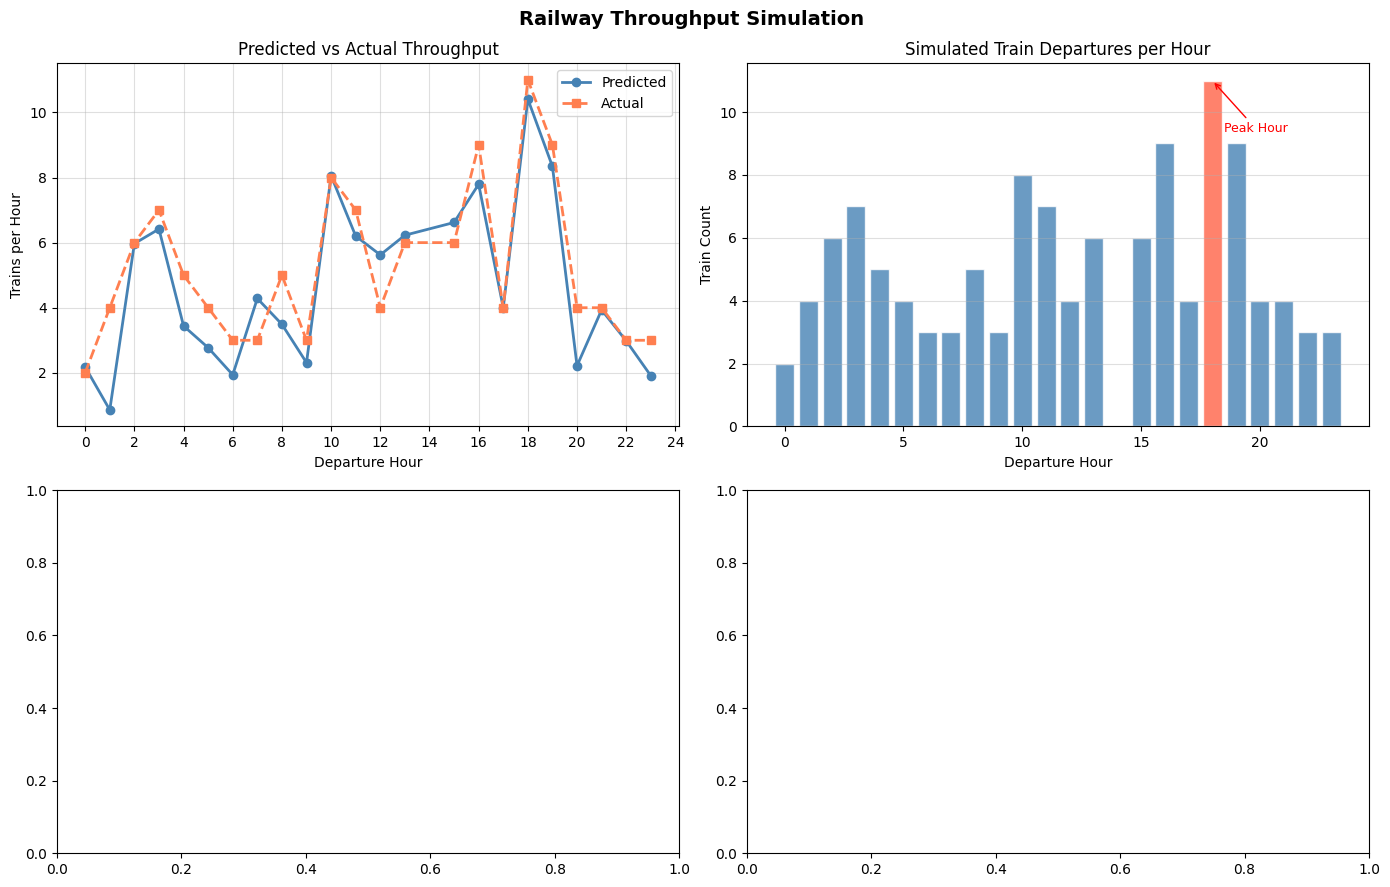

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Railway Throughput Simulation ', fontsize=14, fontweight='bold')

hours = hourly_sim['dept_hour']
pred  = hourly_sim['predicted_throughput']
actual = hourly_sim['actual_throughput']

# Plot 1: Predicted vs Actual throughput
ax1 = axes[0, 0]
ax1.plot(hours, pred,   marker='o', label='Predicted', color='steelblue', linewidth=2)
ax1.plot(hours, actual, marker='s', label='Actual',    color='coral',     linewidth=2, linestyle='--')
ax1.set_title('Predicted vs Actual Throughput')
ax1.set_xlabel('Departure Hour')
ax1.set_ylabel('Trains per Hour')
ax1.legend()
ax1.grid(True, alpha=0.4)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Plot 2: Bar chart — trains scheduled per hour 
ax2 = axes[0, 1]
bar_colors = ['tomato' if h == max_hour else 'steelblue' for h in hours]
ax2.bar(hours, actual, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.set_title('Simulated Train Departures per Hour')
ax2.set_xlabel('Departure Hour')
ax2.set_ylabel('Train Count')
ax2.grid(True, axis='y', alpha=0.4)
ax2.annotate('Peak Hour', xy=(max_hour, actual[hourly_sim['dept_hour']==max_hour].values[0]),
             xytext=(max_hour+0.5, actual.max()*0.85),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# saving the plots
plt.tight_layout()
plt.savefig('simulation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Detailed Hourly Report**

In [9]:
# detailed hourly report and congestion status based on predicted throughput
report = hourly_sim[['dept_hour', 'headway', 'num_trains',
                      'actual_throughput', 'predicted_throughput']].copy()
report['predicted_throughput'] = report['predicted_throughput'].round(2)
report['headway'] = report['headway'].round(3)
report['hour_label'] = report['dept_hour'].apply(lambda h: f"{int(h):02d}:00")
report['capacity_flag'] = report['predicted_throughput'].apply(
    lambda x: 'PEAK' if x >= max_pred * 0.85 else ('HIGH' if x >= avg_pred else 'NORMAL')
)
report = report[['hour_label','headway','num_trains',
                 'predicted_throughput','capacity_flag']]
report.columns = ['Hour', 'Avg_Headway', 'Trains',
                  'Pred_Throughput', 'Congestion_Status']
report

,Hour,Avg_Headway,Trains,Pred_Throughput,Congestion_Status
0,00:00,0.000,2,2.18,NORMAL
1,01:00,0.250,4,0.86,NORMAL
2,02:00,0.167,6,5.97,HIGH
3,03:00,0.143,7,6.42,HIGH
4,04:00,0.200,5,3.44,NORMAL
5,05:00,0.250,4,2.77,NORMAL
6,06:00,0.333,3,1.94,NORMAL
7,07:00,0.333,3,4.28,NORMAL
8,08:00,0.200,5,3.49,NORMAL
9,09:00,0.333,3,2.31,NORMAL
